# AIML Lab 4 - AI-Based Medical Prognosis using Logistic Regression

**Aim:** implement an AI-based medical prognosis system using patient clinical
data and a Machine Learning classification model to predict a future medical
outcome.

**Dataset:** Heart Failure Clinical Records (UCI) - 299 patients followed up
after heart failure.

**Target:** `DEATH_EVENT` - `0` = survived during follow-up, `1` = died during
follow-up.

**Steps covered:** load and explore -> preprocess and scale -> train a Logistic
Regression model -> evaluate with accuracy and a confusion matrix -> predict the
prognosis of a new patient.

## Part A - Load and Explore the Dataset

### A1. Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### A2. Load the healthcare dataset

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

### A3. Number of records and features

In [3]:
print("Number of Patients:", df.shape[0])
print("Number of Features:", df.shape[1] - 1, "(excluding the target DEATH_EVENT)")
print()
print("Columns:")
for col in df.columns:
    print(" -", col)

Number of Patients: 299
Number of Features: 12 (excluding the target DEATH_EVENT)

Columns:
 - age
 - anaemia
 - creatinine_phosphokinase
 - diabetes
 - ejection_fraction
 - high_blood_pressure
 - platelets
 - serum_creatinine
 - serum_sodium
 - sex
 - smoking
 - time
 - DEATH_EVENT


### A4. First five patient records

In [4]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


### A5. Target class distribution

In [5]:
counts = df["DEATH_EVENT"].value_counts().sort_index()

print("Survived Patients (DEATH_EVENT = 0):", counts[0])
print("Death Events      (DEATH_EVENT = 1):", counts[1])
print()
print("Survived: {:.1f} %".format(counts[0] / len(df) * 100))
print("Died:     {:.1f} %".format(counts[1] / len(df) * 100))

Survived Patients (DEATH_EVENT = 0): 203
Death Events      (DEATH_EVENT = 1): 96

Survived: 67.9 %
Died:     32.1 %


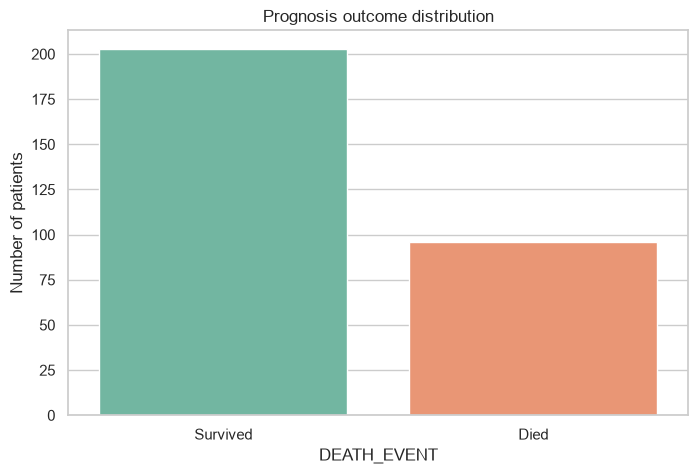

In [6]:
sns.countplot(x="DEATH_EVENT", data=df, hue="DEATH_EVENT", palette="Set2", legend=False)

plt.title("Prognosis outcome distribution")
plt.xticks([0, 1], ["Survived", "Died"])
plt.xlabel("DEATH_EVENT")
plt.ylabel("Number of patients")
plt.show()

### A6. Check for missing values

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total Missing Values:", int(df.isnull().sum().sum()))

Missing values per column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total Missing Values: 0


## Part B - Preprocess the Patient Data

### B1. Select the relevant clinical features

The seven clinical features used for the prognosis model:

`age`, `ejection_fraction`, `serum_creatinine`, `serum_sodium`, `diabetes`,
`high_blood_pressure`, `smoking`

The `time` column (length of the follow-up period) is deliberately **left out**.
It is recorded *after* the outcome is known - a patient who died early has a
short follow-up time - so training on it would leak the answer into the model
and would not be available for a new patient at admission.

In [8]:
FEATURES = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "diabetes",
    "high_blood_pressure",
    "smoking",
]
TARGET = "DEATH_EVENT"

print("Input Features:", len(FEATURES))
for f in FEATURES:
    print(" -", f)
print()
print("Target Variable:", TARGET)

Input Features: 7
 - age
 - ejection_fraction
 - serum_creatinine
 - serum_sodium
 - diabetes
 - high_blood_pressure
 - smoking

Target Variable: DEATH_EVENT


### B2. Separate the input features X and the prognosis target y

In [9]:
X = df[FEATURES]
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (299, 7)
y shape: (299,)


,age,ejection_fraction,serum_creatinine,serum_sodium,diabetes,high_blood_pressure,smoking
0,75.0,20,1.9,130,0,1,0
1,55.0,38,1.1,136,0,0,0
2,65.0,20,1.3,129,0,0,1
3,50.0,20,1.9,137,0,0,0
4,65.0,20,2.7,116,1,0,0


### B3. Check and handle missing values

In [10]:
missing = X.isnull().sum().sum()
print("Missing values in the selected features:", int(missing))

if missing > 0:                      # median imputation if any turn up
    X = X.fillna(X.median())
    print("Missing values after imputation:", int(X.isnull().sum().sum()))
else:
    print("No imputation needed.")

Missing values in the selected features: 0
No imputation needed.


### B4. Divide the data into training and testing sets (80% / 20%)

`stratify=y` keeps the same survived / died ratio in both sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples: ", len(X_test))
print()
print("Training set - Survived:", int((y_train == 0).sum()), "| Death events:", int((y_train == 1).sum()))
print("Testing set  - Survived:", int((y_test == 0).sum()), "| Death events:", int((y_test == 1).sum()))

Training Samples: 239
Testing Samples:  60

Training set - Survived: 162 | Death events: 77
Testing set  - Survived: 41 | Death events: 19


### B5. Scale the numerical features

The features are on very different scales (age in years, platelets in hundreds
of thousands), so they are standardised to mean 0 and standard deviation 1.

The scaler is fitted on the **training data only** and then applied to the test
data, so no information from the test set leaks into training.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on training data only
X_test_scaled = scaler.transform(X_test)         # apply the same scaling to the test data

print("Feature means before scaling (training set):")
print(X_train.mean().round(2).to_string())
print()
print("Feature means after scaling (training set):", np.round(X_train_scaled.mean(axis=0), 6))
print("Feature std   after scaling (training set):", np.round(X_train_scaled.std(axis=0), 6))

Feature means before scaling (training set):
age                     61.07
ejection_fraction       37.89
serum_creatinine         1.39
serum_sodium           136.53
diabetes                 0.45
high_blood_pressure      0.37
smoking                  0.32

Feature means after scaling (training set): [ 0.  0. -0.  0. -0.  0.  0.]
Feature std   after scaling (training set): [1. 1. 1. 1. 1. 1. 1.]


## Part C - Build and Train a Machine Learning Prognosis Model

### C1. Create and train the Logistic Regression model

In [13]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained.")
print("Number of features used:", model.n_features_in_)

Model trained.
Number of features used: 7


### C2. Generate predictions and prediction probabilities

In [14]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Column 1 of predict_proba is the probability of class 1 (death)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted probabilities of death:", np.round(y_test_prob[:10], 3))
print("First 10 predicted labels:                ", y_test_pred[:10])

First 10 predicted probabilities of death: [0.37  0.257 0.109 0.398 0.046 0.119 0.045 0.146 0.12  0.654]
First 10 predicted labels:                 [0 0 0 0 0 0 0 0 0 1]


### C3. Training and testing accuracy

In [15]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc * 100:.2f} %")
print(f"Testing Accuracy:  {test_acc * 100:.2f} %")

Training Accuracy: 76.57 %
Testing Accuracy:  68.33 %


### C4. What the model learned

A positive coefficient pushes the prediction towards **death**, a negative one
towards **survival**.

In [16]:
coefficients = pd.Series(model.coef_[0], index=FEATURES).sort_values()
print(coefficients.round(3).to_string())

ejection_fraction     -0.819
serum_sodium          -0.117
smoking                0.095
diabetes               0.245
high_blood_pressure    0.269
age                    0.473
serum_creatinine       0.799


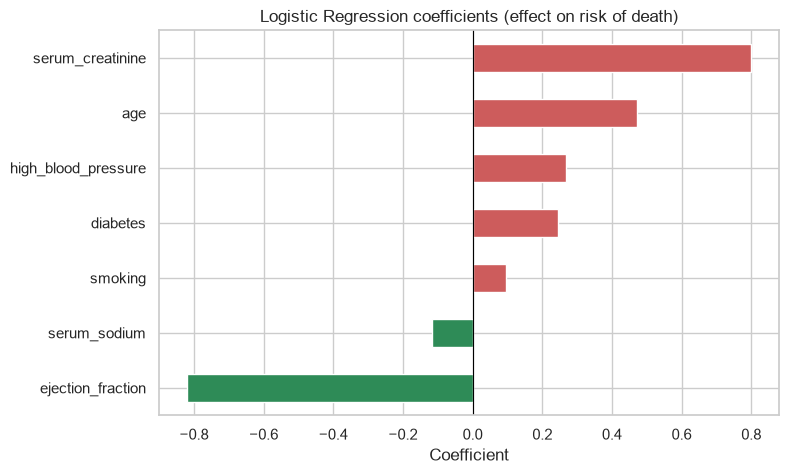

In [17]:
colors = ["seagreen" if c < 0 else "indianred" for c in coefficients]
coefficients.plot(kind="barh", color=colors)

plt.title("Logistic Regression coefficients (effect on risk of death)")
plt.xlabel("Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

### C5. Example prognosis for a single patient

In [18]:
example = pd.DataFrame([{
    "age": 65,
    "ejection_fraction": 30,
    "serum_creatinine": 1.8,
    "serum_sodium": 135,
    "diabetes": 1,
    "high_blood_pressure": 1,
    "smoking": 0,
}])[FEATURES]

prob = model.predict_proba(scaler.transform(example))[0, 1]

print("Patient: 65 years")
print("Ejection Fraction: 30")
print("Serum Creatinine: 1.8")
print()
print(f"Predicted Probability of Death: {prob:.4f}")
print("Predicted Prognosis:", "Death" if prob >= 0.5 else "Survival")

Patient: 65 years
Ejection Fraction: 30
Serum Creatinine: 1.8

Predicted Probability of Death: 0.6612
Predicted Prognosis: Death


## Part D - Evaluate and Predict Medical Prognosis

### D1. Classification accuracy on the test patients

In [19]:
print(f"Correct Predictions: {int((y_test_pred == y_test).sum())} / {len(y_test)}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.2f} %")

Correct Predictions: 41 / 60
Test Accuracy: 68.33 %


### D2. Confusion matrix

In [20]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()
print("True Negative  (Survived, predicted Survived):", tn)
print("False Positive (Survived, predicted Death):   ", fp)
print("False Negative (Died,     predicted Survived):", fn)
print("True Positive  (Died,     predicted Death):   ", tp)

Confusion Matrix:
[[35  6]
 [13  6]]

True Negative  (Survived, predicted Survived): 35
False Positive (Survived, predicted Death):    6
False Negative (Died,     predicted Survived): 13
True Positive  (Died,     predicted Death):    6


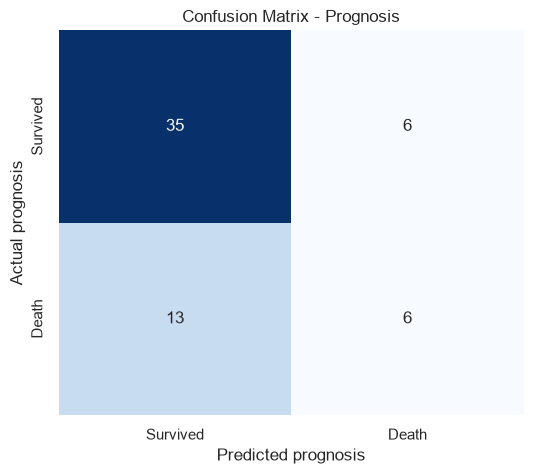

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Survived", "Death"], yticklabels=["Survived", "Death"])

plt.title("Confusion Matrix - Prognosis")
plt.xlabel("Predicted prognosis")
plt.ylabel("Actual prognosis")
plt.show()

In [22]:
print(classification_report(y_test, y_test_pred, target_names=["Survived", "Death"]))

              precision    recall  f1-score   support

    Survived       0.73      0.85      0.79        41
       Death       0.50      0.32      0.39        19

    accuracy                           0.68        60
   macro avg       0.61      0.58      0.59        60
weighted avg       0.66      0.68      0.66        60



False negatives matter most here: a patient who died but was predicted to
survive is the case a clinician would least want the model to miss.

### Reducing the false negatives

Only about a third of the patients in the dataset died, so the model can score
well simply by predicting "Survived" too often - which is why the recall on
death events is low. Setting `class_weight="balanced"` makes Logistic Regression
treat an error on a death event as more costly, in proportion to how rare that
class is.

In [23]:
balanced_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
balanced_model.fit(X_train_scaled, y_train)

y_test_pred_bal = balanced_model.predict(X_test_scaled)
cm_bal = confusion_matrix(y_test, y_test_pred_bal)

print(f"Test Accuracy (balanced): {accuracy_score(y_test, y_test_pred_bal) * 100:.2f} %")
print()
print("Confusion Matrix:")
print(cm_bal)
print()
print("False Negatives - plain model:   ", cm[1, 0])
print("False Negatives - balanced model:", cm_bal[1, 0])

Test Accuracy (balanced): 73.33 %

Confusion Matrix:
[[32  9]
 [ 7 12]]

False Negatives - plain model:    13
False Negatives - balanced model: 7


In [24]:
print(classification_report(y_test, y_test_pred_bal, target_names=["Survived", "Death"]))

              precision    recall  f1-score   support

    Survived       0.82      0.78      0.80        41
       Death       0.57      0.63      0.60        19

    accuracy                           0.73        60
   macro avg       0.70      0.71      0.70        60
weighted avg       0.74      0.73      0.74        60



The plain model is kept for the rest of the experiment, since Part C specifies a
standard Logistic Regression model.

### D3. Actual vs predicted prognosis for selected patients

In [25]:
LABELS = {0: "Survived", 1: "Death"}

results = pd.DataFrame({
    "Actual": y_test.map(LABELS).values,
    "Predicted": pd.Series(y_test_pred).map(LABELS).values,
    "Probability of Death": np.round(y_test_prob, 3),
})
results["Correct"] = np.where(results["Actual"] == results["Predicted"], "yes", "no")

for i in range(8):
    row = results.iloc[i]
    print(f"Patient {i + 1}")
    print(f"  Actual:    {row['Actual']}")
    print(f"  Predicted: {row['Predicted']}  (probability of death = {row['Probability of Death']})")

Patient 1
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.37)
Patient 2
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.257)
Patient 3
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.109)
Patient 4
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.398)
Patient 5
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.046)
Patient 6
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.119)
Patient 7
  Actual:    Survived
  Predicted: Survived  (probability of death = 0.045)
Patient 8
  Actual:    Death
  Predicted: Survived  (probability of death = 0.146)


In [26]:
# The patients the model got wrong
wrong = results[results["Correct"] == "no"]
print("Misclassified test patients:", len(wrong), "out of", len(results))
wrong.head(10)

Misclassified test patients:

 19 out of 60


,Actual,Predicted,Probability of Death,Correct
7,Death,Survived,0.146,no
9,Survived,Death,0.654,no
10,Death,Survived,0.487,no
11,Death,Survived,0.388,no
12,Death,Survived,0.311,no
14,Death,Survived,0.066,no
15,Death,Survived,0.498,no
17,Death,Survived,0.308,no
18,Survived,Death,0.629,no
25,Survived,Death,0.546,no


### D4. Predict the prognosis of a new patient

In [27]:
new_patient = pd.DataFrame([{
    "age": 65,
    "ejection_fraction": 30,
    "serum_creatinine": 1.8,
    "serum_sodium": 135,
    "diabetes": 1,
    "high_blood_pressure": 1,
    "smoking": 0,
}])[FEATURES]

print("New patient record:")
print(new_patient.T.rename(columns={0: "value"}).to_string())

New patient record:
                     value
age                   65.0
ejection_fraction     30.0
serum_creatinine       1.8
serum_sodium         135.0
diabetes               1.0
high_blood_pressure    1.0
smoking                0.0


In [28]:
new_scaled = scaler.transform(new_patient)          # same scaling as the training data
new_prob = model.predict_proba(new_scaled)[0, 1]
new_pred = model.predict(new_scaled)[0]

print(f"Predicted Probability of Death: {new_prob:.4f}")
print("Predicted Prognosis:", LABELS[new_pred])

Predicted Probability of Death: 0.6612
Predicted Prognosis: Death


### A second new patient, for comparison

A younger patient with a healthy ejection fraction and normal serum creatinine.

In [29]:
low_risk_patient = pd.DataFrame([{
    "age": 45,
    "ejection_fraction": 60,
    "serum_creatinine": 0.9,
    "serum_sodium": 140,
    "diabetes": 0,
    "high_blood_pressure": 0,
    "smoking": 0,
}])[FEATURES]

low_prob = model.predict_proba(scaler.transform(low_risk_patient))[0, 1]

print(f"Predicted Probability of Death: {low_prob:.4f}")
print("Predicted Prognosis:", "Death" if low_prob >= 0.5 else "Survival")

Predicted Probability of Death: 0.0170
Predicted Prognosis: Survival


## Result

The AI-based medical prognosis system was implemented using patient clinical
data and a Logistic Regression model. The model was trained on historical heart
failure patient records and used to predict whether a patient survives the
follow-up period. Its performance was evaluated using accuracy and a confusion
matrix.

The predicted prognosis is intended to assist healthcare professionals and is
not a replacement for clinical judgment.